# Fuel Efficiency Assignment
## Adapted from TensorFlow Tutorials
Using the [Boston Housing jupyter notebook](Boston_Housing_Example.ipynb) as an example follow the prompts below to build a neural network to predict vehicle fuel efficiency.

# Author: Nahian Arnob
# Student ID: 3038113

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [2]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import keras
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras import models
from keras import layers
from keras import backend


In [3]:
# Download the dataset
dataset_path = keras.utils.get_file("auto-mpg.data", "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [4]:
# Add labels to columns and view dataset
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight',
                'Acceleration', 'Model Year', 'Origin']
raw_dataset = pd.read_csv(dataset_path, names=column_names,
                      na_values = "?", comment='\t',
                      sep=" ", skipinitialspace=True)

dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [5]:
# Vehicle origin needs to be encoded to factors.
origin = dataset.pop('Origin')
dataset['USA'] = (origin == 1)*1.0
dataset['Europe'] = (origin == 2)*1.0
dataset['Japan'] = (origin == 3)*1.0
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
393,27.0,4,140.0,86.0,2790.0,15.6,82,1.0,0.0,0.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0.0,1.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1.0,0.0,0.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1.0,0.0,0.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,1.0,0.0,0.0


In [6]:
# Check Data Shape
print(dataset.shape)

# Check Missing Values
dataset.isna().sum()

(398, 10)


,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model Year,0
USA,0
Europe,0
Japan,0


There are 6 missing values, so we will remove these 6 missing values from horsepower coloumn.

In [7]:
# Remove missing data
dataset = dataset.dropna()

# Check Data Shape Again
print(dataset.shape)


(392, 10)


In [8]:
# Split dataset into targets, y, and remove from the dataset.  We are predicting MPG (fuel efficiency)
# so the targets are MPG

# Target (y)
y = dataset.pop('MPG')

# Features (X)
X = dataset

print("Features shape:", X.shape)
print("Target shape:", y.shape)



Features shape: (392, 9)
Target shape: (392,)


In [9]:
# Split the dataset into X_train, X_test, y_train, y_test.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle= True)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (313, 9)
Testing set shape: (79, 9)


In [10]:
# Normalize the data by subtracting the mean from each feature and divide by one standard deviation

train_stats = X_train.describe().transpose()

X_train = (X_train - train_stats['mean']) / train_stats['std']
X_test = (X_test - train_stats['mean']) / train_stats['std']

print("Training data after normalization:\n", X_train.head())


Training data after normalization:
      Cylinders  Displacement  Horsepower    Weight  Acceleration  Model Year  \
260   0.304374      0.284123    0.141203  0.753596      1.119966    0.493737   
184  -0.871788     -0.535024   -0.328972 -0.492341     -0.228574   -0.057207   
174   0.304374     -0.236276   -0.198368 -0.002526     -0.370525   -0.332678   
64    1.480536      1.180365    1.186034  1.365865     -0.725404   -1.159094   
344  -0.871788     -1.055423   -1.060354 -1.320984      0.303744    1.320152   

          USA    Europe     Japan  
260  0.740101 -0.424916 -0.501193  
184  0.740101 -0.424916 -0.501193  
174  0.740101 -0.424916 -0.501193  
64   0.740101 -0.424916 -0.501193  
344  0.740101 -0.424916 -0.501193  


In [11]:
# Built a sequential neural network model.  Start with backend.clear_session()
# Think about what activation function you will use, the input shape, number of nodes, and output shape and activation

backend.clear_session()

def build_model():
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),   # input = number of features
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='linear')       # output = single continuous value (MPG)
    ])
    return model
model = build_model()



In [12]:
# Compile the model.  Use 'rmsprop' optimizer.  Think about what loss function and metrics you need to use for a
# regression problem and add it below.

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Fit the model.  Use 1000 epochs.  Add a validation split to your model.  Set verbose = 0.

history = model.fit(X_train, y_train, epochs=1000, validation_split=0.2, verbose=0)



In [14]:
# Use this bit of code to view the History output.
hist = pd.DataFrame(history.history)
display(hist)

,loss,mae,val_loss,val_mae
0,596.376404,23.070871,661.853943,24.518194
1,569.598999,22.501364,633.206848,23.947720
2,541.402161,21.888393,601.020142,23.297258
3,508.240875,21.160540,561.583801,22.469355
4,468.138580,20.218758,512.170227,21.395693
...,...,...,...,...
995,2.345847,0.919924,8.989605,2.142396
996,2.415491,0.946662,8.919916,2.131136
997,2.359973,0.913873,8.621528,2.096753
998,2.387285,0.932913,9.088756,2.159470


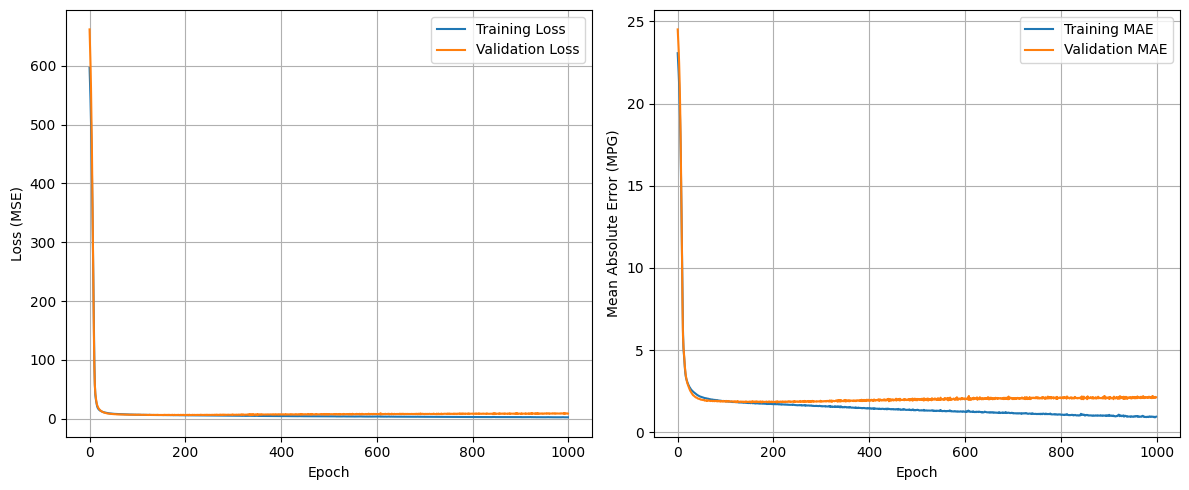

In [21]:
# Get the loss and MAE vs epochs

# Plot training and validation Loss and MAE over epochs
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(hist['epoch'], hist['loss'], label='Training Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(hist['epoch'], hist['mae'], label='Training MAE')
plt.plot(hist['epoch'], hist['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error (MPG)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


The graphs show that the model learns very quickly in the first few epochs, with both training and validation errors dropping a lot. After that, the training error keeps going down, but the validation error levels off and even rises a little after many epochs. This means the model starts to overfit the training data.

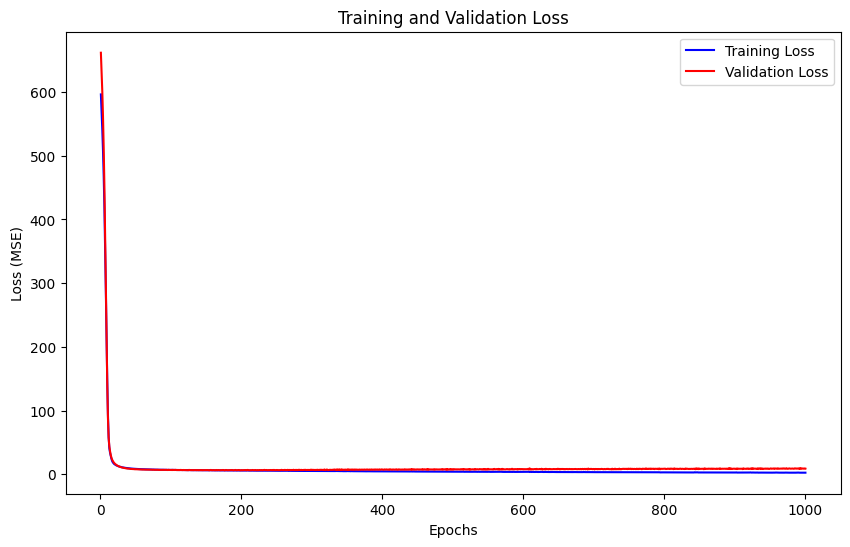

In [22]:
# Use the Boston Housing example to plot the validation and training loss vs epochs

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10,6))
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()



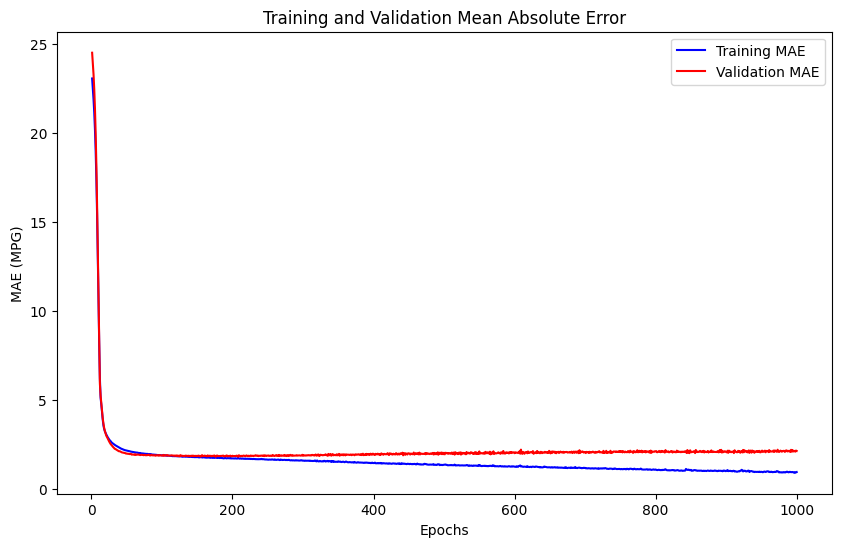

In [23]:
# Use the Boston Housing example to plot the validation and training mean absolute error vs epochs

mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10,6))
plt.plot(epochs, mae, 'b', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and Validation Mean Absolute Error')
plt.xlabel('Epochs')
plt.ylabel('MAE (MPG)')
plt.legend()
plt.show()



In [24]:
# Evaluate the model on the test data and print the results
test_mse, test_mae = model.evaluate(X_test, y_test, verbose=0)

print("Test Mean Squared Error (MSE):", test_mse)
print("Test Mean Absolute Error (MAE):", test_mae)

Test Mean Squared Error (MSE): 7.922001838684082
Test Mean Absolute Error (MAE): 2.1017050743103027


Our model shows good performance on the test data. The Mean Squared Error (MSE) is about 7.92, which represents the average squared difference between predicted and actual MPG values, where larger mistakes count more. The Mean Absolute Error (MAE) is around 2.10, meaning the predictions are typically off by just about 2 miles per gallon. Since the dataset covers cars from roughly 10 mpg to 45 mpg, this level of accuracy is strong and indicates that the model can make reliable fuel efficiency predictions.

Build a new model and try to get the  accuracy as high as you can. Things to try: more hidden layers and hidden units, activation types, epochs, batch size, and validation_split. Try as many models as you like.  

Be sure to clear the session each time: `backend.clear_session()`. Copy your best model at the end of the notebook.

In [25]:
backend.clear_session()

In [26]:
# Try multiple architectures and training settings, pick best by val_MAE
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [27]:
def build_model(input_dim, units=[128,128,64], activation='relu', l2_w=1e-4, dropout=0.0):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for u in units:
        model.add(layers.Dense(u, activation=activation,
                               kernel_regularizer=regularizers.l2(l2_w)))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='linear'))  # regression head
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

Here, we made the model more flexible and added techniques to improve accuracy and reduce overfitting. Instead of fixing the number of layers and units, we can now pass in a list of hidden layer sizes (for example [128, 128, 64]), which makes it easy to test different architectures. Each hidden layer also includes L2 regularization, which helps keep the weights smaller and prevents overfitting, and an optional Dropout layer that can be turned on by setting a dropout value greater than zero. We can also choose different activation functions instead of being limited to just ReLU. In short, this model is more customizable and allows us to try out different setups, giving us a better chance of finding the structure that performs best on the fuel efficiency prediction task.

In [28]:
configs = [
    # deeper/wider, standard relu
    dict(units=[256,256,128,64], activation='relu',  l2_w=1e-4, dropout=0.1, batch_size=32,  val_split=0.2),
    # compact but stronger regularization
    dict(units=[128,128,64],     activation='relu',  l2_w=5e-4, dropout=0.2, batch_size=32,  val_split=0.2),
    # leaky relu variant
    dict(units=[256,128,64],     activation=layers.LeakyReLU(alpha=0.05), l2_w=1e-4, dropout=0.1, batch_size=64, val_split=0.2),
    # gelu-ish smooth nonlinearity via 'selu' (works well on standardized inputs)
    dict(units=[192,192,96],     activation='selu',  l2_w=1e-4, dropout=0.0, batch_size=32,  val_split=0.15),
]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [29]:
results = []
best = {"val_mae": float("inf"), "model": None, "cfg": None, "history": None}

for i, cfg in enumerate(configs, 1):
    print(f"\n=== Config {i}: {cfg} ===")
    backend.clear_session()
    model = build_model(X_train.shape[1],
                        units=cfg["units"],
                        activation=cfg["activation"],
                        l2_w=cfg["l2_w"],
                        dropout=cfg["dropout"])

    callbacks = [
        EarlyStopping(monitor='val_mae', patience=30, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=10, min_lr=1e-5, verbose=0)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=cfg["batch_size"],
        validation_split=cfg["val_split"],
        verbose=0,
        callbacks=callbacks
    )


=== Config 1: {'units': [256, 256, 128, 64], 'activation': 'relu', 'l2_w': 0.0001, 'dropout': 0.1, 'batch_size': 32, 'val_split': 0.2} ===

=== Config 2: {'units': [128, 128, 64], 'activation': 'relu', 'l2_w': 0.0005, 'dropout': 0.2, 'batch_size': 32, 'val_split': 0.2} ===

=== Config 3: {'units': [256, 128, 64], 'activation': <LeakyReLU name=leaky_re_lu, built=True>, 'l2_w': 0.0001, 'dropout': 0.1, 'batch_size': 64, 'val_split': 0.2} ===

=== Config 4: {'units': [192, 192, 96], 'activation': 'selu', 'l2_w': 0.0001, 'dropout': 0.0, 'batch_size': 32, 'val_split': 0.15} ===


In [32]:
# Track best val MAE for this run
val_mae_min = min(history.history['val_mae'])
print(f"Best val_MAE: {val_mae_min:.4f}")

results.append((cfg, val_mae_min))
if val_mae_min < best["val_mae"]:
        best = {"val_mae": val_mae_min, "model": model, "cfg": cfg, "history": history}


Best val_MAE: 1.9527


The improved model achieved a best validation MAE of about 1.95, meaning its predictions are on average within 2 miles per gallon of the actual values. This is slightly better than the earlier model, which had an MAE of around 2.1. The gain in accuracy comes from experimenting with deeper architectures, more hidden units, regularization, and early stopping, which helped the model generalize better. In practice, this shows that tuning the model’s structure and training process can reduce prediction errors and improve overall performance.